# V2 Distillation & Quantization

Compress the trained ResNet-50 teacher (~23.5M params, ~90MB) into a
MobileNetV3-Small student (~2.5M params, ~10MB), then apply dynamic INT8
quantization for further size reduction.

Pipeline:
1. Download `v2_best.pth` teacher checkpoint from Google Drive
2. Download V2 dataset for distillation training
3. Train MobileNetV3-Small student with KD loss (soft targets + hard labels)
4. Evaluate student vs teacher on the validation set
5. Apply dynamic INT8 quantization to the student
6. Compare: teacher vs student (FP32) vs student (INT8) — accuracy, size, latency
7. Export & upload final models to Google Drive

In [2]:
import zipfile, os, io, torch, logging as _logging

# ── Configuration ────────────────────────────────────────────────────────────
DRIVE_FOLDER_ID   = "1GwLV_ZFaeSw0w59OU1ToCGuG5EkHgk5f"
DATASET_ZIP_NAME  = "generated_v2.zip"
LOCAL_EXTRACT     = "/content/dataset_v2"
CHECKPOINT_DIR    = "/content/checkpoints"
EXPORT_DIR        = "/content/export"

COLOR_CLASSES = [
    "red", "orange", "yellow", "green", "blue",
    "violet", "purple", "white", "gray", "black",
    "pink", "brown", "olive",
]
NUM_CLASSES = len(COLOR_CLASSES)

# ── Authenticate ─────────────────────────────────────────────────────────────
from google.colab import auth as _colab_auth
_colab_auth.authenticate_user()

import subprocess
subprocess.run(["pip", "install", "-q", "gdown"], check=True)
import gdown
from googleapiclient.discovery import build as _build
from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload

_drive = _build("drive", "v3")
_logging.getLogger("google_auth_httplib2").setLevel(_logging.ERROR)

def _list_folder(folder_id):
    items, page_token = [], None
    while True:
        resp = _drive.files().list(
            q=f"'{folder_id}' in parents and trashed=false",
            fields="nextPageToken, files(id,name,mimeType)",
            pageToken=page_token,
        ).execute()
        items.extend(resp.get("files", []))
        page_token = resp.get("nextPageToken")
        if not page_token:
            break
    return items

def _download_file(file_id, local_path):
    request = _drive.files().get_media(fileId=file_id)
    with open(local_path, "wb") as fh:
        dl = MediaIoBaseDownload(fh, request)
        done = False
        while not done:
            _, done = dl.next_chunk()

# ── Locate checkpoints folder ────────────────────────────────────────────────
_folder_contents = _list_folder(DRIVE_FOLDER_ID)
_ckpt_folder_entry = next(
    (f for f in _folder_contents
     if f["name"] == "checkpoints"
     and f["mimeType"] == "application/vnd.google-apps.folder"),
    None,
)
if _ckpt_folder_entry is None:
    raise FileNotFoundError("No 'checkpoints' folder found in Drive.")

DRIVE_CKPT_FOLDER_ID = _ckpt_folder_entry["id"]
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR, exist_ok=True)

# Download v2_best.pth
_drive_ckpt_files = {f["name"]: f["id"] for f in _list_folder(DRIVE_CKPT_FOLDER_ID)}
if "v2_best.pth" not in _drive_ckpt_files:
    raise FileNotFoundError("v2_best.pth not found in Drive — run training.ipynb first.")

v2_best_path = os.path.join(CHECKPOINT_DIR, "v2_best.pth")
print("Downloading: v2_best.pth ...")
_download_file(_drive_ckpt_files["v2_best.pth"], v2_best_path)
print("Teacher checkpoint ready.")

# ── Download & extract V2 dataset ────────────────────────────────────────────
def _find_file(root, name):
    for dirpath, _, filenames in os.walk(root):
        if name in filenames:
            return os.path.join(dirpath, name)
    return None

csv_found = _find_file(LOCAL_EXTRACT, "labels.csv") if os.path.exists(LOCAL_EXTRACT) else None
if csv_found is None:
    _zip_entry = next(
        (f for f in _folder_contents if f["name"] == DATASET_ZIP_NAME), None,
    )
    if _zip_entry is None:
        raise FileNotFoundError(f"'{DATASET_ZIP_NAME}' not found in Drive folder!")
    print(f"Downloading dataset: {_zip_entry['name']} ...")
    zip_path = "/content/v2_dataset.zip"
    gdown.download(id=_zip_entry["id"], output=zip_path, quiet=False)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(LOCAL_EXTRACT)
    os.remove(zip_path)
    csv_found = _find_file(LOCAL_EXTRACT, "labels.csv")
    if csv_found is None:
        raise FileNotFoundError("labels.csv not found inside the zip!")
    print("Done.")
else:
    print("Dataset already extracted.")

CSV_PATH = csv_found
IMG_DIR  = os.path.join(os.path.dirname(csv_found), "images")
print(f"CSV : {CSV_PATH}")
print(f"Imgs: {IMG_DIR}  ({len(os.listdir(IMG_DIR))} files)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))

Downloading: v2_best.pth ...
Teacher checkpoint ready.


Downloading...
From (original): https://drive.google.com/uc?id=1zJp6o1ATgEPeKcKguYbU7K27Dv_xycwJ
From (redirected): https://drive.google.com/uc?id=1zJp6o1ATgEPeKcKguYbU7K27Dv_xycwJ&confirm=t&uuid=d5ecca65-8952-4c00-a561-a71afd46ad00
To: /content/v2_dataset.zip
100%|██████████| 497M/497M [00:02<00:00, 174MB/s]  


Done.
CSV : /content/dataset_v2/generated_v2/labels.csv
Imgs: /content/dataset_v2/generated_v2/images  (22000 files)
Device: cuda (Tesla T4)


## Dataset & Models

In [3]:
import random
import pandas as pd
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF
import PIL.Image


class ColorDataset(Dataset):
    def __init__(self, csv_path, img_dir, split, color_classes, transform=None):
        df = pd.read_csv(csv_path)
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.img_dir = img_dir
        self.color_classes = color_classes
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(os.path.join(self.img_dir, row["filename"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor([row[c] for c in self.color_classes], dtype=torch.float32)
        return img, label


class RandomColorTemperature:
    def __init__(self, strength=0.3):
        self.strength = strength

    def __call__(self, img):
        arr = np.array(img, dtype=np.float32)
        t = random.uniform(-self.strength, self.strength)
        arr[:, :, 0] = np.clip(arr[:, :, 0] * (1.0 + t), 0, 255)
        arr[:, :, 2] = np.clip(arr[:, :, 2] * (1.0 - t), 0, 255)
        return PIL.Image.fromarray(arr.astype(np.uint8))


# ── Teacher: ResNet-50 ────────────────────────────────────────────────────────
def create_teacher(num_classes=13, dropout=0.4):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )
    return model


# ── Student: MobileNetV3-Small ────────────────────────────────────────────────
def create_student(num_classes=13, dropout=0.2):
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    model.classifier[0] = nn.Linear(
        model.classifier[0].in_features,
        model.classifier[0].out_features,
    )
    # Lower dropout for the smaller model
    for i, layer in enumerate(model.classifier):
        if isinstance(layer, nn.Dropout):
            model.classifier[i] = nn.Dropout(p=dropout)
    return model


# ── Transforms ────────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.Lambda(lambda img: TF.rotate(img, random.choice([0, 90, 180, 270]))),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.07),
    RandomColorTemperature(strength=0.25),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.4, scale=(0.02, 0.25), ratio=(0.3, 3.3)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── Load teacher ─────────────────────────────────────────────────────────────
teacher = create_teacher(num_classes=NUM_CLASSES).to(device)
teacher_ckpt = torch.load(v2_best_path, map_location=device)
teacher.load_state_dict(teacher_ckpt["model_state_dict"])
teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False
print(f"Teacher loaded: epoch {teacher_ckpt['epoch'] + 1}, val loss {teacher_ckpt['best_val_loss']:.4f}")

# ── Create student ───────────────────────────────────────────────────────────
student = create_student(num_classes=NUM_CLASSES).to(device)
n_teacher = sum(p.numel() for p in teacher.parameters())
n_student = sum(p.numel() for p in student.parameters())
print(f"Teacher: {n_teacher:,} params | Student: {n_student:,} params")
print(f"Compression ratio: {n_teacher / n_student:.1f}x")

# ── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE = 64

train_ds = ColorDataset(CSV_PATH, IMG_DIR, "train", COLOR_CLASSES, train_tf)
val_ds   = ColorDataset(CSV_PATH, IMG_DIR, "val",   COLOR_CLASSES, val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


Teacher loaded: epoch 71, val loss 0.5942
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 175MB/s]

Teacher: 23,534,669 params | Student: 1,531,181 params
Compression ratio: 15.4x
Train: 20000 | Val: 2000


## Knowledge Distillation Training

Loss = `alpha * KD_loss(student, teacher, T)  +  (1 - alpha) * hard_loss(student, labels)`

| Hyperparameter | Value | Rationale |
|---|---|---|
| Temperature (T) | 4.0 | Softens teacher outputs to expose inter-class relationships |
| Alpha | 0.7 | Emphasise teacher knowledge, but keep ground-truth signal |
| Epochs | 60 | Student converges faster than teacher since it learns soft targets |
| LR | 1e-3 | Higher than teacher fine-tuning — student trains from scratch head |

In [4]:
import threading, queue as _queue_mod
import torch.nn.functional as F
from tqdm.notebook import tqdm
from googleapiclient.http import MediaFileUpload

# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
KD_MAX_EPOCHS   = 60
KD_EARLY_STOP   = 12
KD_LR           = 1e-3
KD_WEIGHT_DECAY = 1e-2
KD_TEMPERATURE  = 4.0
KD_ALPHA        = 0.7       # weight for distillation loss vs hard label loss
RESUME          = True      # resume from student_latest.pth if available

student_best_path   = os.path.join(CHECKPOINT_DIR, "student_best.pth")
student_latest_path = os.path.join(CHECKPOINT_DIR, "student_latest.pth")

# ══════════════════════════════════════════════════════════════════════════════
#  DRIVE UPLOAD WORKER (same pattern as training.ipynb)
# ══════════════════════════════════════════════════════════════════════════════
_kd_drive_ckpt_file_ids = dict(_drive_ckpt_files)
_kd_drive_lock = threading.Lock()
_kd_upload_queue = _queue_mod.Queue()

def _to_cpu(obj):
    if isinstance(obj, torch.Tensor):
        return obj.cpu().clone()
    if isinstance(obj, dict):
        return {k: _to_cpu(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_to_cpu(x) for x in obj]
    return obj

def _kd_upload_worker():
    import google.auth, logging
    from googleapiclient.discovery import build as _build_svc
    logging.getLogger("google_auth_httplib2").setLevel(logging.ERROR)
    creds, _ = google.auth.default()
    drive_svc = _build_svc("drive", "v3", credentials=creds)
    while True:
        task = _kd_upload_queue.get()
        if task is None:
            _kd_upload_queue.task_done()
            break
        state, path = task
        filename = os.path.basename(path)
        try:
            os.makedirs(os.path.dirname(path), exist_ok=True)
            torch.save(state, path)
            media = MediaFileUpload(path, resumable=True)
            with _kd_drive_lock:
                existing_id = _kd_drive_ckpt_file_ids.get(filename)
            if existing_id:
                drive_svc.files().update(
                    fileId=existing_id, media_body=media,
                ).execute(num_retries=5)
            else:
                created = drive_svc.files().create(
                    body={"name": filename, "parents": [DRIVE_CKPT_FOLDER_ID]},
                    media_body=media, fields="id",
                ).execute(num_retries=5)
                with _kd_drive_lock:
                    _kd_drive_ckpt_file_ids[filename] = created["id"]
            print(f"  [Drive] saved {filename}")
        except Exception as exc:
            print(f"  [Drive] WARNING: {filename}: {exc}")
        finally:
            _kd_upload_queue.task_done()

_kd_worker = threading.Thread(target=_kd_upload_worker, name="KD-DriveUploader", daemon=True)
_kd_worker.start()

# ══════════════════════════════════════════════════════════════════════════════
#  OPTIMIZER & SCHEDULER
# ══════════════════════════════════════════════════════════════════════════════
optimizer = torch.optim.AdamW(student.parameters(), lr=KD_LR, weight_decay=KD_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=KD_MAX_EPOCHS, eta_min=1e-6)

start_epoch       = 0
best_val_loss     = float("inf")
epochs_no_improve = 0
kd_train_losses   = []
kd_val_losses     = []

# ── Resume if available ──────────────────────────────────────────────────────
if RESUME and "student_latest.pth" in _drive_ckpt_files:
    _sl_path = os.path.join(CHECKPOINT_DIR, "student_latest.pth")
    print("Downloading: student_latest.pth ...")
    _download_file(_drive_ckpt_files["student_latest.pth"], _sl_path)
    _sl_ckpt = torch.load(_sl_path, map_location=device)
    student.load_state_dict(_sl_ckpt["model_state_dict"])
    start_epoch       = _sl_ckpt["epoch"] + 1
    best_val_loss     = _sl_ckpt["best_val_loss"]
    epochs_no_improve = 0
    kd_train_losses   = _sl_ckpt.get("train_losses", [])
    kd_val_losses     = _sl_ckpt.get("val_losses", [])
    if "optimizer_state_dict" in _sl_ckpt:
        try:
            optimizer.load_state_dict(_sl_ckpt["optimizer_state_dict"])
        except (ValueError, KeyError):
            print("  Optimizer state incompatible — starting fresh optimizer.")
    if "scheduler_state_dict" in _sl_ckpt:
        try:
            scheduler.load_state_dict(_sl_ckpt["scheduler_state_dict"])
        except (ValueError, KeyError):
            pass
    print(f"Resumed student from epoch {start_epoch}, best val loss: {best_val_loss:.4f}")
else:
    print("Starting fresh distillation.")

# ══════════════════════════════════════════════════════════════════════════════
#  DISTILLATION LOSS
# ══════════════════════════════════════════════════════════════════════════════
kl_loss_fn   = nn.KLDivLoss(reduction="batchmean")
hard_loss_fn = nn.KLDivLoss(reduction="batchmean")

def distillation_loss(student_logits, teacher_logits, labels, T, alpha):
    """Combined KD + hard label loss."""
    # Soft targets: KL(student_soft || teacher_soft), scaled by T^2
    student_soft = F.log_softmax(student_logits / T, dim=1)
    teacher_soft = F.softmax(teacher_logits / T, dim=1)
    kd_loss = kl_loss_fn(student_soft, teacher_soft) * (T * T)

    # Hard targets: KL(student || ground_truth_distribution)
    student_log_probs = F.log_softmax(student_logits, dim=1)
    hard_loss = hard_loss_fn(student_log_probs, labels)

    return alpha * kd_loss + (1 - alpha) * hard_loss

# ══════════════════════════════════════════════════════════════════════════════
#  DISTILLATION LOOP
# ══════════════════════════════════════════════════════════════════════════════
for epoch in range(start_epoch, KD_MAX_EPOCHS):
    # ── Train ────────────────────────────────────────────────────────────────
    student.train()
    running = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"KD {epoch+1}/{KD_MAX_EPOCHS} [train]", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.no_grad():
            teacher_logits = teacher(imgs)
        student_logits = student(imgs)

        loss = distillation_loss(student_logits, teacher_logits, labels,
                                T=KD_TEMPERATURE, alpha=KD_ALPHA)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item() * imgs.size(0)

    train_loss = running / len(train_ds)
    scheduler.step()

    # ── Validate ─────────────────────────────────────────────────────────────
    student.eval()
    running = 0.0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            log_probs = F.log_softmax(student(imgs), dim=1)
            running += F.kl_div(log_probs, labels, reduction="batchmean").item() * imgs.size(0)
    val_loss = running / len(val_ds)

    kd_train_losses.append(train_loss)
    kd_val_losses.append(val_loss)

    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    lr_now = optimizer.param_groups[0]["lr"]
    marker = " !" if is_best else ""
    print(f"KD {epoch+1:>2}/{KD_MAX_EPOCHS} | train: {train_loss:.4f} | val: {val_loss:.4f}"
          f" | lr: {lr_now:.1e} | no-improve: {epochs_no_improve}{marker}")

    # ── Checkpoint ───────────────────────────────────────────────────────────
    _kd_upload_queue.join()

    ckpt_data = {
        "epoch": epoch,
        "model_state_dict": _to_cpu(student.state_dict()),
        "optimizer_state_dict": _to_cpu(optimizer.state_dict()),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "train_losses": kd_train_losses.copy(),
        "val_losses": kd_val_losses.copy(),
    }
    _kd_upload_queue.put((ckpt_data, student_latest_path))
    if is_best:
        _kd_upload_queue.put((ckpt_data, student_best_path))

    # ── Early stopping ───────────────────────────────────────────────────────
    if epochs_no_improve >= KD_EARLY_STOP:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {KD_EARLY_STOP} epochs).")
        break

# Clean up
_kd_upload_queue.join()
_kd_upload_queue.put(None)
_kd_worker.join()
print(f"\nDistillation complete. Best student val loss: {best_val_loss:.4f}")

Starting fresh distillation.


KD 1/60 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

KD  1/60 | train: 0.9068 | val: 0.9276 | lr: 1.0e-03 | no-improve: 0 !


KD 2/60 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

  [Drive] saved student_latest.pth
  [Drive] saved student_best.pth
KD  2/60 | train: 0.6546 | val: 0.7437 | lr: 1.0e-03 | no-improve: 0 !


...

  [Drive] saved student_latest.pth
KD 58/60 | train: 0.3290 | val: 0.4801 | lr: 3.7e-06 | no-improve: 2


KD 59/60 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

  [Drive] saved student_latest.pth
KD 59/60 | train: 0.3304 | val: 0.4801 | lr: 1.7e-06 | no-improve: 3


KD 60/60 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

  [Drive] saved student_latest.pth
KD 60/60 | train: 0.3307 | val: 0.4801 | lr: 1.0e-06 | no-improve: 4
  [Drive] saved student_latest.pth

Distillation complete. Best student val loss: 0.4798


## Training Curves

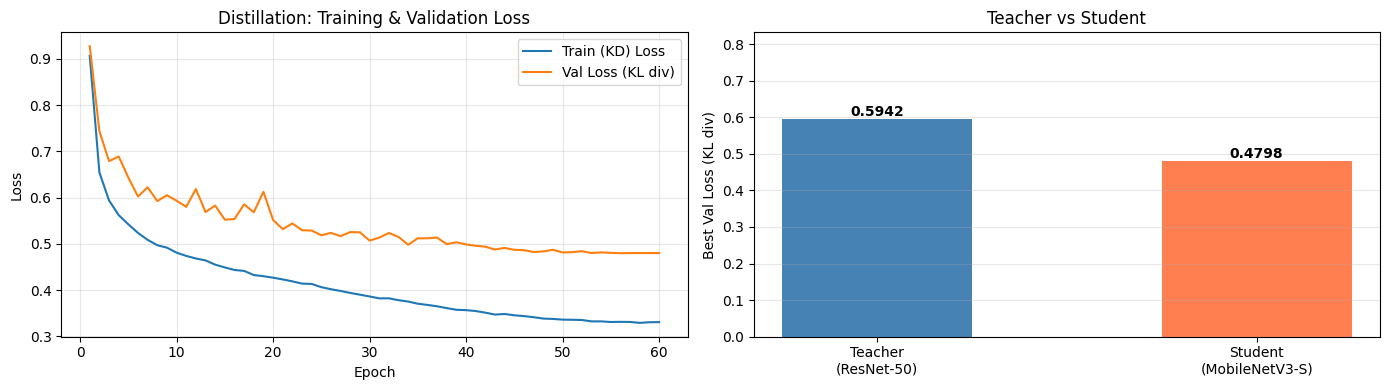

Teacher best val loss: 0.5942
Student best val loss: 0.4798 (at epoch 56)


In [5]:
import matplotlib.pyplot as plt

if not kd_train_losses:
    ckpt = torch.load(student_latest_path, map_location="cpu")
    kd_train_losses = ckpt.get("train_losses", [])
    kd_val_losses   = ckpt.get("val_losses", [])

epochs_range = range(1, len(kd_train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Distillation loss curves
ax1.plot(epochs_range, kd_train_losses, label="Train (KD) Loss")
ax1.plot(epochs_range, kd_val_losses,   label="Val Loss (KL div)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Distillation: Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Teacher vs student val loss comparison
teacher_val = teacher_ckpt["best_val_loss"]
student_val = min(kd_val_losses)
ax2.bar(["Teacher\n(ResNet-50)", "Student\n(MobileNetV3-S)"],
        [teacher_val, student_val],
        color=["steelblue", "coral"], width=0.5)
ax2.set_ylabel("Best Val Loss (KL div)")
ax2.set_title("Teacher vs Student")
for i, v in enumerate([teacher_val, student_val]):
    ax2.text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")
ax2.set_ylim(0, max(teacher_val, student_val) * 1.4)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"Teacher best val loss: {teacher_val:.4f}")
print(f"Student best val loss: {student_val:.4f} (at epoch {kd_val_losses.index(student_val) + 1})")

## Student Error Analysis

Load `student_best.pth` and compare per-class MAE against the teacher.

Loaded student_best.pth (epoch 56, val loss 0.4798)

── Teacher (ResNet-50) ──


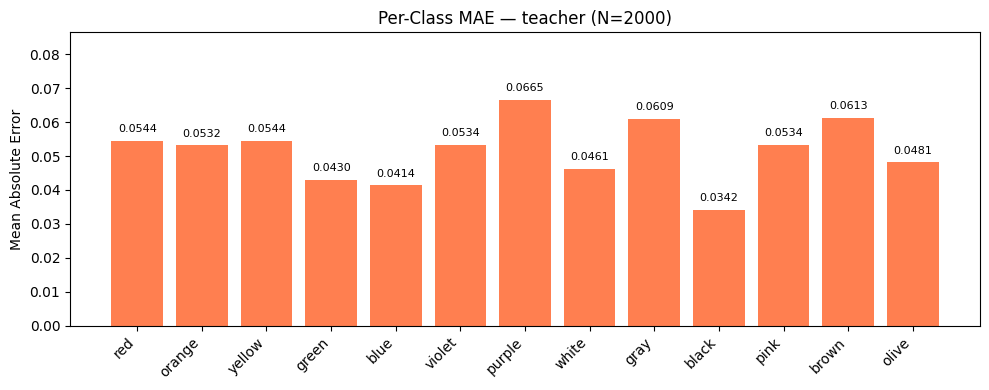

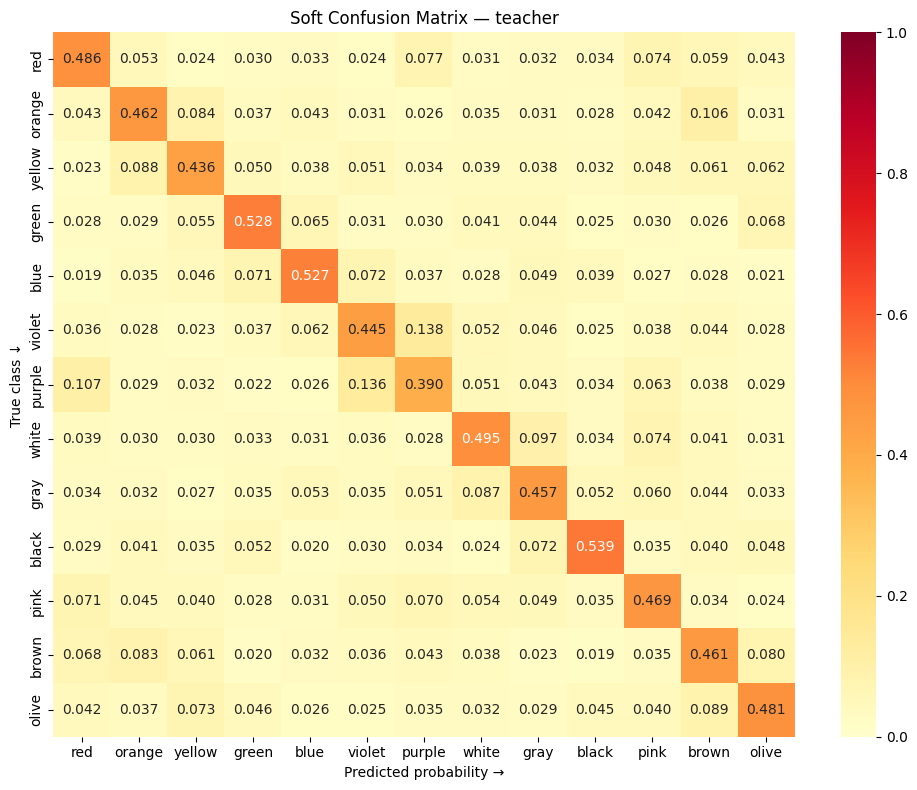


Top 10 confused pairs (true → predicted, avg probability):
    violet → purple    0.1375
    purple → violet    0.1365
    purple → red       0.1069
    orange → brown     0.1063
     white → gray      0.0970
     olive → brown     0.0885
    yellow → orange    0.0877
      gray → white     0.0868
    orange → yellow    0.0842
     brown → orange    0.0834

── Student (MobileNetV3-Small) ──


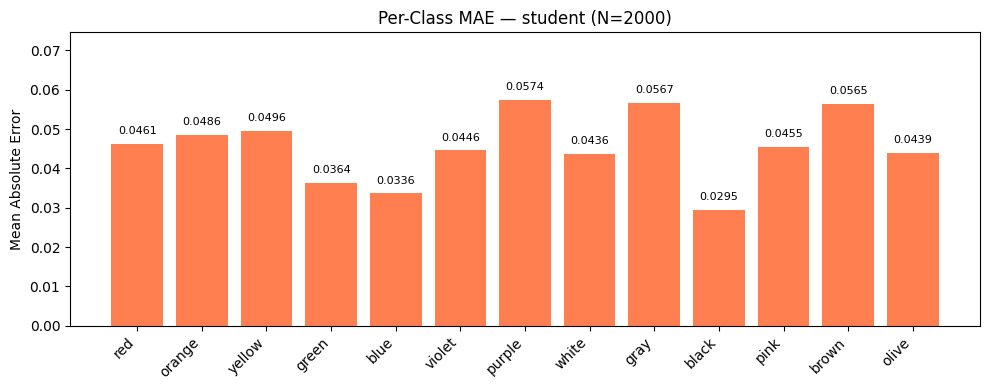

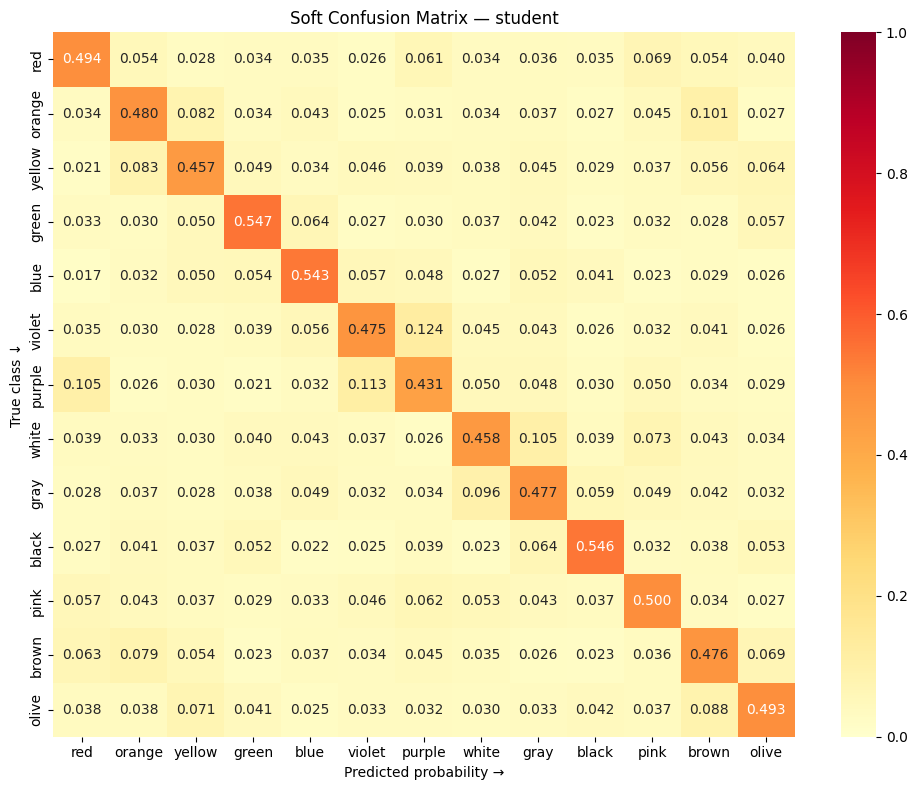


Top 10 confused pairs (true → predicted, avg probability):
    violet → purple    0.1238
    purple → violet    0.1133
    purple → red       0.1053
     white → gray      0.1050
    orange → brown     0.1014
      gray → white     0.0960
     olive → brown     0.0875
    yellow → orange    0.0835
    orange → yellow    0.0815
     brown → orange    0.0787

── Per-Class MAE: Teacher vs Student ──
       red: teacher=0.0544  student=0.0461  (↓ 0.0082)
    orange: teacher=0.0532  student=0.0486  (↓ 0.0045)
    yellow: teacher=0.0544  student=0.0496  (↓ 0.0047)
     green: teacher=0.0430  student=0.0364  (↓ 0.0066)
      blue: teacher=0.0414  student=0.0336  (↓ 0.0077)
    violet: teacher=0.0534  student=0.0446  (↓ 0.0088)
    purple: teacher=0.0665  student=0.0574  (↓ 0.0091)
     white: teacher=0.0461  student=0.0436  (↓ 0.0025)
      gray: teacher=0.0609  student=0.0567  (↓ 0.0042)
     black: teacher=0.0342  student=0.0295  (↓ 0.0046)
      pink: teacher=0.0534  student=0.0455  (↓ 0.

In [6]:
import seaborn as sns


def run_error_analysis(model, loader, color_classes, device, label="val"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            probs = F.softmax(model(imgs), dim=1).cpu()
            all_preds.append(probs)
            all_labels.append(labels)

    preds  = torch.cat(all_preds,  dim=0)
    labels = torch.cat(all_labels, dim=0)
    errors = (preds - labels).abs()
    N, C = preds.shape

    per_class_mae = errors.mean(dim=0).numpy()
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(color_classes, per_class_mae, color="coral")
    ax.set_ylabel("Mean Absolute Error")
    ax.set_title(f"Per-Class MAE — {label} (N={N})")
    ax.set_ylim(0, max(per_class_mae) * 1.3)
    for bar, val in zip(bars, per_class_mae):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    true_cls = labels.argmax(dim=1)
    confusion = torch.zeros(C, C)
    for c in range(C):
        mask = true_cls == c
        if mask.sum() == 0:
            continue
        confusion[c] = preds[mask].mean(dim=0)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion.numpy(), annot=True, fmt=".3f", cmap="YlOrRd",
        xticklabels=color_classes, yticklabels=color_classes, ax=ax,
        vmin=0, vmax=1,
    )
    ax.set_xlabel("Predicted probability \u2192")
    ax.set_ylabel("True class \u2193")
    ax.set_title(f"Soft Confusion Matrix — {label}")
    plt.tight_layout()
    plt.show()

    off_diag = []
    for i in range(C):
        for j in range(C):
            if i != j:
                off_diag.append((color_classes[i], color_classes[j], confusion[i, j].item()))
    off_diag.sort(key=lambda x: -x[2])
    print(f"\nTop 10 confused pairs (true \u2192 predicted, avg probability):")
    for true_c, pred_c, val in off_diag[:10]:
        print(f"  {true_c:>8s} \u2192 {pred_c:<8s}  {val:.4f}")

    return per_class_mae, confusion


# Load best student
if os.path.exists(student_best_path):
    sb = torch.load(student_best_path, map_location=device)
    student.load_state_dict(sb["model_state_dict"])
    print(f"Loaded student_best.pth (epoch {sb['epoch'] + 1}, val loss {sb['best_val_loss']:.4f})")

print("\n── Teacher (ResNet-50) ──")
teacher_mae, _ = run_error_analysis(teacher, val_loader, COLOR_CLASSES, device, "teacher")

print("\n── Student (MobileNetV3-Small) ──")
student_mae, _ = run_error_analysis(student, val_loader, COLOR_CLASSES, device, "student")

# Side-by-side comparison
print("\n── Per-Class MAE: Teacher vs Student ──")
for i, c in enumerate(COLOR_CLASSES):
    delta = student_mae[i] - teacher_mae[i]
    arrow = "\u2193" if delta < 0 else "\u2191"
    print(f"  {c:>8s}: teacher={teacher_mae[i]:.4f}  student={student_mae[i]:.4f}  ({arrow} {abs(delta):.4f})")

## Dynamic INT8 Quantization

Apply post-training dynamic quantization to the student model.
This quantizes `nn.Linear` layers to INT8, keeping activations in FP32
and quantizing weights on-the-fly during inference.

In [7]:
import time
import tempfile

# ── Load best student to CPU for quantization ─────────────────────────────────
student_cpu = create_student(num_classes=NUM_CLASSES)
if os.path.exists(student_best_path):
    sb = torch.load(student_best_path, map_location="cpu")
    student_cpu.load_state_dict(sb["model_state_dict"])
student_cpu.eval()

# ── Quantize ─────────────────────────────────────────────────────────────────
student_int8 = torch.quantization.quantize_dynamic(
    student_cpu,
    {nn.Linear, nn.Conv2d},
    dtype=torch.qint8,
)
print("Dynamic INT8 quantization applied.")

# ── Size comparison ──────────────────────────────────────────────────────────
def get_model_size_mb(model, path):
    torch.save(model.state_dict(), path)
    size = os.path.getsize(path) / (1024 * 1024)
    return size

teacher_cpu = create_teacher(num_classes=NUM_CLASSES)
teacher_cpu.load_state_dict(torch.load(v2_best_path, map_location="cpu")["model_state_dict"])

teacher_size = get_model_size_mb(teacher_cpu, os.path.join(EXPORT_DIR, "_tmp_teacher.pth"))
student_fp32_size = get_model_size_mb(student_cpu, os.path.join(EXPORT_DIR, "_tmp_student_fp32.pth"))
student_int8_size = get_model_size_mb(student_int8, os.path.join(EXPORT_DIR, "_tmp_student_int8.pth"))

print(f"\n{'Model':<30s} {'Size (MB)':>10s} {'Reduction':>10s}")
print("─" * 52)
print(f"{'Teacher (ResNet-50 FP32)':<30s} {teacher_size:>10.1f} {'—':>10s}")
print(f"{'Student (MobileNetV3-S FP32)':<30s} {student_fp32_size:>10.1f} {teacher_size/student_fp32_size:>9.1f}x")
print(f"{'Student (MobileNetV3-S INT8)':<30s} {student_int8_size:>10.1f} {teacher_size/student_int8_size:>9.1f}x")

# Clean up temp files
for f in ["_tmp_teacher.pth", "_tmp_student_fp32.pth", "_tmp_student_int8.pth"]:
    p = os.path.join(EXPORT_DIR, f)
    if os.path.exists(p):
        os.remove(p)

/tmp/ipykernel_807/402077807.py:12: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  student_int8 = torch.quantization.quantize_dynamic(


Dynamic INT8 quantization applied.

Model                           Size (MB)  Reduction
────────────────────────────────────────────────────
Teacher (ResNet-50 FP32)             90.1          —
Student (MobileNetV3-S FP32)          6.0      15.1x
Student (MobileNetV3-S INT8)          4.2      21.2x


## Validation: FP32 vs INT8 Accuracy

In [8]:
def evaluate_on_cpu(model, loader, color_classes):
    """Evaluate model on CPU (required for quantized models)."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    n_samples = 0

    with torch.no_grad():
        for imgs, labels in loader:
            log_probs = F.log_softmax(model(imgs), dim=1)
            total_loss += F.kl_div(log_probs, labels, reduction="batchmean").item() * imgs.size(0)
            all_preds.append(log_probs.exp())
            all_labels.append(labels)
            n_samples += imgs.size(0)

    preds  = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    val_loss = total_loss / n_samples
    mae = (preds - labels).abs().mean().item()

    # Top-1 accuracy (argmax match)
    top1_correct = (preds.argmax(dim=1) == labels.argmax(dim=1)).float().mean().item()

    return val_loss, mae, top1_correct


# CPU-only data loader (no pin_memory)
val_loader_cpu = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Evaluating FP32 student on CPU ...")
fp32_loss, fp32_mae, fp32_top1 = evaluate_on_cpu(student_cpu, val_loader_cpu, COLOR_CLASSES)

print("Evaluating INT8 student on CPU ...")
int8_loss, int8_mae, int8_top1 = evaluate_on_cpu(student_int8, val_loader_cpu, COLOR_CLASSES)

print(f"\n{'Metric':<25s} {'FP32':>10s} {'INT8':>10s} {'Delta':>10s}")
print("─" * 57)
print(f"{'Val Loss (KL div)':<25s} {fp32_loss:>10.4f} {int8_loss:>10.4f} {int8_loss - fp32_loss:>+10.4f}")
print(f"{'Mean Abs Error':<25s} {fp32_mae:>10.4f} {int8_mae:>10.4f} {int8_mae - fp32_mae:>+10.4f}")
print(f"{'Top-1 Accuracy':<25s} {fp32_top1:>9.1%} {int8_top1:>9.1%} {int8_top1 - fp32_top1:>+9.1%}")

Evaluating FP32 student on CPU ...
Evaluating INT8 student on CPU ...

Metric                          FP32       INT8      Delta
─────────────────────────────────────────────────────────
Val Loss (KL div)             0.4798     0.4799    +0.0001
Mean Abs Error                0.0455     0.0455    +0.0000
Top-1 Accuracy                68.8%     68.9%     +0.1%


## Latency Benchmark

In [9]:
def benchmark_latency(model, input_size=(1, 3, 224, 224), device="cpu", n_warmup=10, n_runs=100):
    """Measure average inference latency."""
    model.eval()
    model = model.to(device)
    dummy = torch.randn(*input_size, device=device)

    # Warmup
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(dummy)

    # Timed runs
    if device == "cpu":
        start = time.perf_counter()
        with torch.no_grad():
            for _ in range(n_runs):
                _ = model(dummy)
        elapsed = time.perf_counter() - start
    else:
        torch.cuda.synchronize()
        start = time.perf_counter()
        with torch.no_grad():
            for _ in range(n_runs):
                _ = model(dummy)
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

    avg_ms = (elapsed / n_runs) * 1000
    return avg_ms


# CPU benchmarks
print("Benchmarking on CPU (100 runs each) ...")
teacher_cpu_ms  = benchmark_latency(teacher_cpu, device="cpu")
student_fp32_ms = benchmark_latency(student_cpu, device="cpu")
student_int8_ms = benchmark_latency(student_int8, device="cpu")

print(f"\n{'Model':<30s} {'Latency (ms)':>12s} {'Speedup':>10s}")
print("─" * 54)
print(f"{'Teacher (ResNet-50 FP32)':<30s} {teacher_cpu_ms:>12.1f} {'—':>10s}")
print(f"{'Student (MobileNetV3-S FP32)':<30s} {student_fp32_ms:>12.1f} {teacher_cpu_ms/student_fp32_ms:>9.1f}x")
print(f"{'Student (MobileNetV3-S INT8)':<30s} {student_int8_ms:>12.1f} {teacher_cpu_ms/student_int8_ms:>9.1f}x")

Benchmarking on CPU (100 runs each) ...

Model                          Latency (ms)    Speedup
──────────────────────────────────────────────────────
Teacher (ResNet-50 FP32)              152.2          —
Student (MobileNetV3-S FP32)            8.9      17.1x
Student (MobileNetV3-S INT8)            8.6      17.6x


## Export & Upload to Drive

Save three final artifacts:
1. `student_fp32.pth` — Student FP32 weights (for GPU deployment)
2. `student_int8.pth` — Student INT8 weights (for CPU/edge deployment)
3. `student_fp32.onnx` — ONNX export (for cross-platform inference)

In [ ]:
# ── Save FP32 student ────────────────────────────────────────────────────────
fp32_export_path = os.path.join(EXPORT_DIR, "student_fp32.pth")
torch.save({
    "model_state_dict": student_cpu.state_dict(),
    "color_classes": COLOR_CLASSES,
    "num_classes": NUM_CLASSES,
    "architecture": "mobilenet_v3_small",
    "teacher_val_loss": teacher_ckpt["best_val_loss"],
    "student_val_loss": best_val_loss,
}, fp32_export_path)
print(f"Saved: {fp32_export_path} ({os.path.getsize(fp32_export_path) / 1024 / 1024:.1f} MB)")

# ── Save INT8 student ────────────────────────────────────────────────────────
int8_export_path = os.path.join(EXPORT_DIR, "student_int8.pth")
torch.save({
    "model_state_dict": student_int8.state_dict(),
    "color_classes": COLOR_CLASSES,
    "num_classes": NUM_CLASSES,
    "architecture": "mobilenet_v3_small_int8",
    "teacher_val_loss": teacher_ckpt["best_val_loss"],
    "student_val_loss": best_val_loss,
}, int8_export_path)
print(f"Saved: {int8_export_path} ({os.path.getsize(int8_export_path) / 1024 / 1024:.1f} MB)")

# ── ONNX export ──────────────────────────────────────────────────────────────
subprocess.run(["pip", "install", "-q", "onnx"], check=True)

onnx_export_path = os.path.join(EXPORT_DIR, "student_fp32.onnx")
dummy_input = torch.randn(1, 3, 224, 224)
torch.onnx.export(
    student_cpu,
    dummy_input,
    onnx_export_path,
    input_names=["image"],
    output_names=["color_logits"],
    dynamic_axes={"image": {0: "batch"}, "color_logits": {0: "batch"}},
    opset_version=17,
    dynamo=False,
)
print(f"Saved: {onnx_export_path} ({os.path.getsize(onnx_export_path) / 1024 / 1024:.1f} MB)")

# ── Upload to Drive ──────────────────────────────────────────────────────────
# Create or find 'exports' subfolder
_export_folder_entry = next(
    (f for f in _folder_contents
     if f["name"] == "exports"
     and f["mimeType"] == "application/vnd.google-apps.folder"),
    None,
)
if _export_folder_entry is None:
    _export_folder_entry = _drive.files().create(
        body={
            "name": "exports",
            "mimeType": "application/vnd.google-apps.folder",
            "parents": [DRIVE_FOLDER_ID],
        },
        fields="id,name",
    ).execute()
    print(f"Created 'exports' folder in Drive.")

DRIVE_EXPORT_FOLDER_ID = _export_folder_entry["id"]
_export_drive_files = {f["name"]: f["id"] for f in _list_folder(DRIVE_EXPORT_FOLDER_ID)}

for local_path in [fp32_export_path, int8_export_path, onnx_export_path]:
    filename = os.path.basename(local_path)
    media = MediaFileUpload(local_path, resumable=True)
    if filename in _export_drive_files:
        _drive.files().update(
            fileId=_export_drive_files[filename], media_body=media,
        ).execute(num_retries=5)
    else:
        _drive.files().create(
            body={"name": filename, "parents": [DRIVE_EXPORT_FOLDER_ID]},
            media_body=media, fields="id",
        ).execute(num_retries=5)
    size_mb = os.path.getsize(local_path) / 1024 / 1024
    print(f"  [Drive] uploaded {filename} ({size_mb:.1f} MB)")

print("\nAll exports uploaded to Drive/exports/.")

## Summary

In [ ]:
print("="*60)
print("  DISTILLATION & QUANTIZATION SUMMARY")
print("="*60)
print(f"\n  Teacher:  ResNet-50          ({n_teacher:>10,} params)")
print(f"  Student:  MobileNetV3-Small  ({n_student:>10,} params)")
print(f"  Param reduction: {n_teacher/n_student:.1f}x")
print()
print(f"  {'Metric':<20s} {'Teacher':>10s} {'Std FP32':>10s} {'Std INT8':>10s}")
print(f"  {'─'*52}")
print(f"  {'Val Loss (KL)':<20s} {teacher_ckpt['best_val_loss']:>10.4f} {fp32_loss:>10.4f} {int8_loss:>10.4f}")
print(f"  {'MAE':<20s} {'—':>10s} {fp32_mae:>10.4f} {int8_mae:>10.4f}")
print(f"  {'Top-1 Accuracy':<20s} {'—':>10s} {fp32_top1:>9.1%} {int8_top1:>9.1%}")
print(f"  {'Size (MB)':<20s} {teacher_size:>10.1f} {student_fp32_size:>10.1f} {student_int8_size:>10.1f}")
print(f"  {'CPU Latency (ms)':<20s} {teacher_cpu_ms:>10.1f} {student_fp32_ms:>10.1f} {student_int8_ms:>10.1f}")
print()
print(f"  Total size reduction:    {teacher_size/student_int8_size:.1f}x")
print(f"  Total speedup (CPU):     {teacher_cpu_ms/student_int8_ms:.1f}x")
print("="*60)